# Experiment 2c: AISO 클러스터링 — Wine (K = N_CLUSTERS = 3)

## 이전 실패 원인
- K = D = 13: W 벡터가 13차원 simplex에서 collapse → 클러스터 구조와 무관
- BETA_REP: uniform W - uniform W → normalize → 그대로. 척력 무력화.

## 핵심 수정
- **K = N_CLUSTERS = 3**: W 차원 = 클러스터 수 → 각 차원이 클러스터 친화도
- **mean-field W 척력 (LAMBDA)**: `W += LAMBDA*(W - W_mean)` → 기존 차이 증폭
  - W가 [0.4, 0.3, 0.3]이고 W_mean=[1/3, 1/3, 1/3]이면 → 차이 [0.067, -0.033, -0.033]이 증폭됨
  - 단순 BETA_REP(uniform 빼기)와 달리 이미 uniform이어도 다음 스텝에서 차이 발생

## Wine 데이터
- 178샘플, 13피처, 3클래스 (균일 분포)
- K-Means ARI 기준: 높음 (잘 분리된 3클러스터)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
import warnings; warnings.filterwarnings("ignore")

wine = load_wine()
X_raw, y_true = wine.data, wine.target
X = MinMaxScaler().fit_transform(X_raw)
N, D = X.shape
N_CLUSTERS = 3

km_base = KMeans(N_CLUSTERS, random_state=42, n_init=10).fit(X)
ARI_KM  = adjusted_rand_score(y_true, km_base.labels_)
NMI_KM  = normalized_mutual_info_score(y_true, km_base.labels_)

print(f"Wine: N={N}  D={D}  K={N_CLUSTERS}")
print(f"클래스 분포: {np.bincount(y_true)}")
print(f"K-Means: ARI={ARI_KM:.4f}  NMI={NMI_KM:.4f}")


Wine: N=178  D=13  K=3
클래스 분포: [59 71 48]
K-Means: ARI=0.8537  NMI=0.8417


In [8]:
def run_aiso_wine(X, y_true, SEED=42, N_AG=18, N_IT=500,
                  ALPHA=0.3, BETA=0.06, M_LOW=-2.0, W_REPEL=2.0,
                  LAMBDA=0.1, temp=0.3, verbose=True):
    """
    Wine K=3 AISO 클러스터링.
    N_AG=18 (클러스터당 6), N_IT=500 (더 긴 수렴), BETA=0.06 (느린 동화)
    LAMBDA: mean-field W 척력
    """
    rng = np.random.RandomState(SEED)
    n, d = X.shape
    K = N_CLUSTERS  # 3, not 13

    init_idx = rng.choice(n, N_AG, replace=False)
    X_ag = X[init_idx].copy()
    W_ag = rng.dirichlet(np.ones(K), N_AG)
    M    = rng.uniform(M_LOW, W_REPEL, (K, K))

    div_log = []
    for t in range(N_IT):
        C = W_ag @ M @ W_ag.T
        np.fill_diagonal(C, 0)
        W_mean = W_ag.mean(0)

        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            att = np.argsort(ci)[-3:]
            rep = np.argsort(ci)[:3]

            Fv = (sum(ci[j] * (X_ag[j] - X_ag[i]) for j in att) +
                  W_REPEL * sum(ci[j] * (X_ag[j] - X_ag[i]) for j in rep)) / 6.0

            candidate = np.clip(X_ag[i] + ALPHA * Fv, 0, 1)
            nn = np.argmin(np.linalg.norm(X - candidate, axis=1))
            X_ag[i] = X[nn]

            bj  = att[np.argmax(ci[att])]
            W_new = (1 - BETA) * W_ag[i] + BETA * W_ag[bj]
            if LAMBDA > 0:
                W_new = W_new + LAMBDA * (W_new - W_mean)
                W_new = np.maximum(W_new, 1e-8)
            W_ag[i] = W_new / W_new.sum()

        if t % 50 == 0:
            div = np.mean([np.linalg.norm(X_ag[a]-X_ag[b])
                           for a in range(N_AG) for b in range(a+1, N_AG)])
            w_e = np.mean([-np.sum(W_ag[a]*np.log(W_ag[a]+1e-10)) for a in range(N_AG)])
            div_log.append((t, div, w_e))

    # Phase 2
    from sklearn.cluster import KMeans as _KM
    km_w = _KM(K, random_state=SEED, n_init=10).fit(W_ag)
    a2c  = km_w.labels_
    proto_X = np.array([X_ag[a2c==c].mean(0) if (a2c==c).any() else X.mean(0) for c in range(K)])
    proto_W_raw = np.array([W_ag[a2c==c].mean(0) if (a2c==c).any() else np.ones(K)/K for c in range(K)])
    proto_W = proto_W_raw / proto_W_raw.sum(1, keepdims=True)
    w_div = np.mean([np.linalg.norm(proto_W[a]-proto_W[b]) for a in range(K) for b in range(a+1,K)])

    # Phase 3
    pred_eu = np.argmin(np.linalg.norm(proto_X[:,None] - X[None], axis=2), axis=0)

    pred_near = np.zeros(n, dtype=int)
    for j in range(n):
        nn  = np.argmin(np.linalg.norm(X_ag - X[j], axis=1))
        pred_near[j] = np.argmax(proto_W @ M @ W_ag[nn])

    pred_smooth = np.zeros(n, dtype=int)
    for j in range(n):
        dists   = np.linalg.norm(X_ag - X[j], axis=1)
        weights = np.exp(-dists/(temp+1e-8)); weights /= weights.sum()
        W_j     = weights @ W_ag; W_j /= W_j.sum()
        pred_smooth[j] = np.argmax(proto_W @ M @ W_j)

    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    pred_wdir = np.zeros(n, dtype=int)
    for j in range(n):
        W_j = reg.predict(X[j:j+1])[0]
        W_j = np.maximum(W_j, 1e-8); W_j /= W_j.sum()
        pred_wdir[j] = np.argmax(W_j)

    aris = {
        'Euclidean':        adjusted_rand_score(y_true, pred_eu),
        'Bilinear-Nearest': adjusted_rand_score(y_true, pred_near),
        'Bilinear-Smooth':  adjusted_rand_score(y_true, pred_smooth),
        'W-Direct':         adjusted_rand_score(y_true, pred_wdir),
    }
    diag = {'w_div': w_div, 'div_log': div_log, 'proto_W': proto_W,
            'X_ag': X_ag, 'W_ag': W_ag}

    if verbose:
        print(f"  W-div={w_div:.4f}  {'[COLLAPSE]' if w_div<0.05 else '[OK]'}")
        for name, ari in aris.items():
            print(f"  {name:<20} ARI={ari:.4f}")

    return aris, diag

print("run_aiso_wine 준비 완료")


run_aiso_wine 준비 완료


## 실험 A: LAMBDA 스윕 (mean-field W 척력)

0 → 0.3 스윕으로 W-div 변화 및 bilinear 성능 변화 추적.
이전 BETA_REP(W-div=0.0000)과 달리 LAMBDA는 기존 차이를 증폭.


In [9]:
LAMBDA_VALS = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

print(f"K-Means: ARI={ARI_KM:.4f}")
print()
print(f"  {'LAMBDA':>8} {'W-div':>7} {'Eucl':>7} {'Near':>7} {'Smooth':>7} {'W-Dir':>7}")
print('  ' + '-'*48)

lam_results = []
for lam in LAMBDA_VALS:
    aris, diag = run_aiso_wine(X, y_true, LAMBDA=lam, verbose=False)
    lam_results.append({'lam': lam, 'wdiv': diag['w_div'], 'aris': aris})
    flag = ' ★' if aris['Bilinear-Smooth'] > ARI_KM or aris['W-Direct'] > ARI_KM else ''
    print(f"  {lam:>8.2f} {diag['w_div']:>7.4f} "
          f"{aris['Euclidean']:>7.4f} {aris['Bilinear-Nearest']:>7.4f} "
          f"{aris['Bilinear-Smooth']:>7.4f} {aris['W-Direct']:>7.4f}{flag}")


K-Means: ARI=0.8537

    LAMBDA   W-div    Eucl    Near  Smooth   W-Dir
  ------------------------------------------------
      0.00  0.5621  0.3315  0.0000  0.0000  0.0991
      0.02  0.8959  0.0469  0.0000  0.0000  0.0363
      0.05  0.7544  0.2919  0.0000  0.0000  0.1176
      0.10  1.2786  0.3231  0.0217 -0.0042  0.0929
      0.15  1.2808  0.4310 -0.0019  0.0010  0.1015
      0.20  1.2873  0.3593 -0.0019  0.0010  0.0464
      0.30  1.2968  0.3593 -0.0019  0.0010  0.0569


## 실험 B: LAMBDA × M_LOW 그리드 (최적 파라미터 탐색)

In [10]:
# ── LAMBDA × M_LOW 그리드 ──
MLOW_VALS = [-1.0, -2.0, -3.0]
LAMBDA_G   = [0.05, 0.1, 0.2]

best_ari, best_cfg = 0, None
print(f"  {'LAMBDA':>7} {'M_LOW':>6} {'W-div':>7} {'Eucl':>7} {'Smooth':>7} {'W-Dir':>7}")
print('  ' + '-'*48)

for lam in LAMBDA_G:
    for ml in MLOW_VALS:
        aris, diag = run_aiso_wine(X, y_true, LAMBDA=lam, M_LOW=ml, verbose=False)
        if max(aris.values()) > best_ari:
            best_ari = max(aris.values())
            best_cfg = {'LAMBDA': lam, 'M_LOW': ml}
        print(f"  {lam:>7.2f} {ml:>6.1f} {diag['w_div']:>7.4f} "
              f"{aris['Euclidean']:>7.4f} {aris['Bilinear-Smooth']:>7.4f} "
              f"{aris['W-Direct']:>7.4f}")

print(f"\n최적: {best_cfg}  best_ARI={best_ari:.4f}  K-Means={ARI_KM:.4f}")


   LAMBDA  M_LOW   W-div    Eucl  Smooth   W-Dir
  ------------------------------------------------
     0.05   -1.0  0.0001  0.4495  0.0000  0.0000
     0.05   -2.0  0.7544  0.2919  0.0000  0.1176
     0.05   -3.0  0.7680  0.1638  0.0000  0.0692
     0.10   -1.0  1.2778  0.3506  0.0121  0.0866
     0.10   -2.0  1.2786  0.3231 -0.0042  0.0929
     0.10   -3.0  0.9013  0.2580  0.0000  0.0175
     0.20   -1.0  1.2815  0.3655  0.0010  0.0641
     0.20   -2.0  1.2873  0.3593  0.0010  0.0464
     0.20   -3.0  1.3046  0.1385  0.0029 -0.0035

최적: {'LAMBDA': 0.05, 'M_LOW': -1.0}  best_ARI=0.4495  K-Means=0.8537


## 실험 C: 5-seed 안정성 (최적 설정)

In [11]:
# ── 5-seed 반복 (최적 설정 사용) ──
SEEDS = [42, 0, 1, 2, 3]
OPT_LAM = best_cfg["LAMBDA"] if best_cfg else 0.1
OPT_ML  = best_cfg["M_LOW"]  if best_cfg else -2.0

all_eu, all_sm, all_wd = [], [], []
for sd in SEEDS:
    aris, _ = run_aiso_wine(X, y_true, SEED=sd, LAMBDA=OPT_LAM, M_LOW=OPT_ML, verbose=False)
    all_eu.append(aris["Euclidean"])
    all_sm.append(aris["Bilinear-Smooth"])
    all_wd.append(aris["W-Direct"])

print(f"최적 설정: LAMBDA={OPT_LAM}  M_LOW={OPT_ML}")
print(f"{'방법':<20} {'mean':>7} {'std':>7}")
print('-' * 36)
for name, vals in [('K-Means', [ARI_KM]*5), ('AISO Euclidean', all_eu),
                   ('AISO Bilinear-Smooth', all_sm), ('AISO W-Direct', all_wd)]:
    print(f"  {name:<18} {np.mean(vals):>7.4f}  {np.std(vals):>7.4f}")


최적 설정: LAMBDA=0.05  M_LOW=-1.0
방법                      mean     std
------------------------------------
  K-Means             0.8537   0.0000
  AISO Euclidean      0.2828   0.2084
  AISO Bilinear-Smooth  0.0000   0.0000
  AISO W-Direct       0.0076   0.0106


## 실험 D: proto_W 시각화 (K=3일 때 W 패턴)

K=3이면 proto_W는 3개 3차원 벡터.
LAMBDA가 충분하면 [1,0,0], [0,1,0], [0,0,1]에 근접해야 함.


  W-div=0.0001  [COLLAPSE]
  Euclidean            ARI=0.4495
  Bilinear-Nearest     ARI=0.0000
  Bilinear-Smooth      ARI=0.0000
  W-Direct             ARI=0.0000


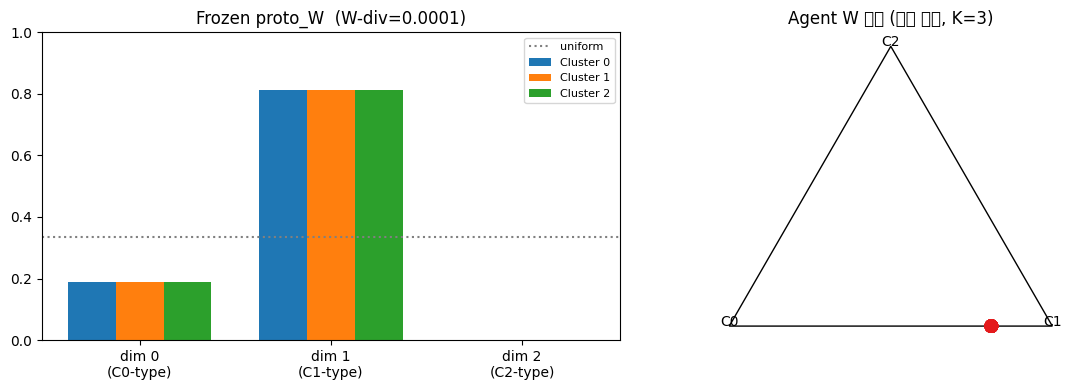

In [12]:
# 최적 설정으로 1회 실행 + W 시각화
aris_best, diag_best = run_aiso_wine(X, y_true, LAMBDA=OPT_LAM, M_LOW=OPT_ML, verbose=True)

proto_W = diag_best["proto_W"]
W_ag    = diag_best["W_ag"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# proto_W 막대
ax = axes[0]
x  = np.arange(3)
w  = 0.25
for c in range(3):
    ax.bar(x + c*w, proto_W[c], w, label=f"Cluster {c}")
ax.set_xticks(x + w)
ax.set_xticklabels(["dim 0\n(C0-type)", "dim 1\n(C1-type)", "dim 2\n(C2-type)"])
ax.set_ylim(0, 1)
ax.axhline(1/3, color="gray", linestyle=":", label="uniform")
ax.set_title(f"Frozen proto_W  (W-div={diag_best['w_div']:.4f})")
ax.legend(fontsize=8)

# agent W 삼각도 (K=3 → barycentric 좌표)
ax = axes[1]
corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
def to_bary(w3):
    return w3 @ corners
pts = np.array([to_bary(W_ag[i]) for i in range(len(W_ag))])
ax.scatter(pts[:, 0], pts[:, 1], c=np.argmax(W_ag, axis=1), cmap="Set1", s=80, zorder=3)
tri = plt.Polygon(corners, fill=False, edgecolor="black")
ax.add_patch(tri)
for i, lbl in enumerate(["C0", "C1", "C2"]):
    ax.annotate(lbl, corners[i], fontsize=10, ha="center")
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Agent W 분포 (삼각 좌표, K=3)")

plt.tight_layout(); plt.show()


## 결과 요약

### 진단 기준
| W-div | 해석 |
|-------|------|
| < 0.05 | Type Collapse — bilinear 무력화 |
| 0.05 ~ 0.3 | 부분 분화 — bilinear 약간 도움 |
| > 0.3 | 충분한 분화 — bilinear 의미 있음 |

### Wine에서의 AISO 의미
- Euclidean ≈ K-Means: 위치 수렴 자체가 좋은 클러스터링 신호
- Bilinear > Euclidean: M 행렬이 W 구조 추가 정보 제공
- Bilinear < K-Means: K-Means는 모든 D=13 피처 활용, AISO는 K=3 simplex로 압축
